<a href="https://www.kaggle.com/code/rajeshkm57/ssl-geometry-dynamics-tracking?scriptVersionId=300438551" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# =========================================================
# Setup
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torchvision.models import resnet18
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

Device: cuda


In [2]:
# =========================================================
# Data
# =========================================================

class TwoCropsTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform
    def __call__(self, x):
        return self.base_transform(x), self.base_transform(x)

ssl_base_transform = T.Compose([
    T.RandomResizedCrop(32, scale=(0.2,1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.4,0.4,0.4,0.1),
    T.RandomGrayscale(p=0.2),
    T.ToTensor()
])

ssl_transform = TwoCropsTransform(ssl_base_transform)

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=ssl_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=T.ToTensor()
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print("Data ready.")

Data ready.


In [3]:
# =========================================================
# Model
# =========================================================

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.backbone = backbone
    def forward(self, x):
        return self.backbone(x)

class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.net(x)

class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.projector = MLP(512)

    def forward(self, x):
        z = self.projector(self.encoder(x))
        return F.normalize(z, dim=1)

In [4]:
def nt_xent_loss(z1, z2, temperature=0.5):
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)

    sim = torch.mm(z, z.t()) / temperature
    mask = torch.eye(2*N, device=z.device).bool()
    sim.masked_fill_(mask, -9e15)

    positives = torch.cat([torch.arange(N,2*N), torch.arange(0,N)]).to(z.device)
    return F.cross_entropy(sim, positives)

In [5]:
def jacobian_frobenius(model, x):
    x = x.clone().detach().to(device).requires_grad_(True)
    y = model(x)
    v = torch.randn_like(y)

    Jv = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=v,
        retain_graph=False
    )[0]

    return torch.sqrt(Jv.pow(2).sum() / x.size(0))

def evaluate_encoder(encoder):
    encoder.eval()
    jac_vals = []
    noise_vals = []

    for i,(x,_) in enumerate(test_loader):
        if i == 3:
            break

        x = x.to(device)

        jac_vals.append(jacobian_frobenius(encoder, x).item())

        noise = torch.randn_like(x)*0.1
        with torch.no_grad():
            f1 = encoder(x)
            f2 = encoder(x+noise)
            noise_vals.append(torch.norm(f1-f2,dim=1).mean().item())

    return np.mean(jac_vals), np.mean(noise_vals)

In [6]:
# =========================================================
# Dynamics Training
# =========================================================

set_seed(42)

model = SimCLR().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

epochs = 500
track_every = 5

history = []
start_time = time.time()

for epoch in range(1, epochs+1):

    epoch_start = time.time()
    model.train()
    total_loss = 0

    for (x1,x2),_ in train_loader:
        x1,x2 = x1.to(device), x2.to(device)

        z1 = model(x1)
        z2 = model(x2)
        loss = nt_xent_loss(z1,z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_time = (time.time()-epoch_start)/60

    print(f"Epoch {epoch:03d}/{epochs} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Time: {epoch_time:.2f}m")

    if epoch % track_every == 0:
        jac, noise = evaluate_encoder(model.encoder)
        history.append({
            "Epoch": epoch,
            "Jacobian": jac,
            "Noise_Sensitivity": noise
        })

        print(f"  >> Tracked at epoch {epoch}: "
              f"Jac={jac:.2f}, Noise={noise:.2f}")

total_time = (time.time()-start_time)/60
print("Total Training Time:", total_time, "minutes")

Epoch 001/500 | Loss: 4.6729 | Time: 0.86m
Epoch 002/500 | Loss: 4.4947 | Time: 0.86m
Epoch 003/500 | Loss: 4.4286 | Time: 0.85m
Epoch 004/500 | Loss: 4.3887 | Time: 0.87m
Epoch 005/500 | Loss: 4.3604 | Time: 0.86m
  >> Tracked at epoch 5: Jac=60.47, Noise=14.63
Epoch 006/500 | Loss: 4.3358 | Time: 0.86m
Epoch 007/500 | Loss: 4.3163 | Time: 0.86m
Epoch 008/500 | Loss: 4.2957 | Time: 0.86m
Epoch 009/500 | Loss: 4.2779 | Time: 0.87m
Epoch 010/500 | Loss: 4.2568 | Time: 0.85m
  >> Tracked at epoch 10: Jac=70.29, Noise=18.22
Epoch 011/500 | Loss: 4.2479 | Time: 0.86m
Epoch 012/500 | Loss: 4.2338 | Time: 0.87m
Epoch 013/500 | Loss: 4.2253 | Time: 0.86m
Epoch 014/500 | Loss: 4.2099 | Time: 0.87m
Epoch 015/500 | Loss: 4.2020 | Time: 0.86m
  >> Tracked at epoch 15: Jac=77.03, Noise=19.25
Epoch 016/500 | Loss: 4.1954 | Time: 0.85m
Epoch 017/500 | Loss: 4.1887 | Time: 0.86m
Epoch 018/500 | Loss: 4.1798 | Time: 0.85m
Epoch 019/500 | Loss: 4.1751 | Time: 0.85m
Epoch 020/500 | Loss: 4.1669 | Time: 

KeyboardInterrupt: 

In [7]:
history_df = pd.DataFrame(history)
history_df.to_csv("geometry_dynamics_tracking.csv", index=False)

print(history_df.head())

   Epoch   Jacobian  Noise_Sensitivity
0      5  60.470174          14.634056
1     10  70.287842          18.220413
2     15  77.025767          19.249982
3     20  76.921959          18.566800
4     25  76.763809          17.565154


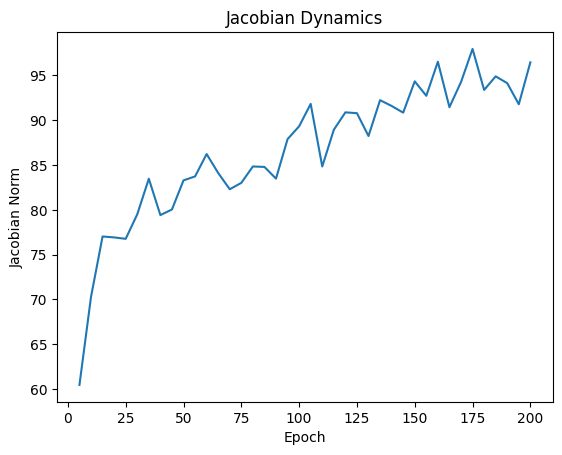

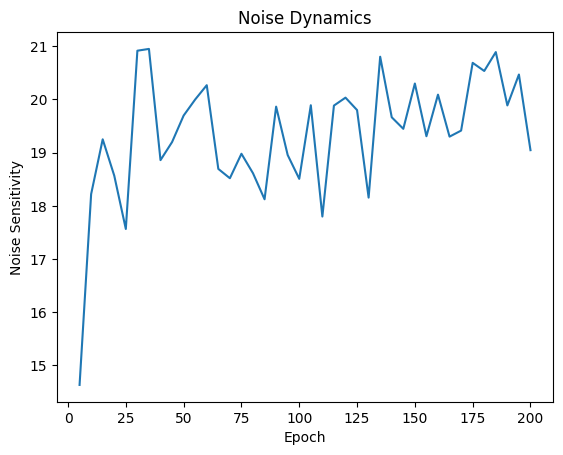

In [8]:
plt.figure()
plt.plot(history_df["Epoch"], history_df["Jacobian"])
plt.xlabel("Epoch")
plt.ylabel("Jacobian Norm")
plt.title("Jacobian Dynamics")
plt.show()

plt.figure()
plt.plot(history_df["Epoch"], history_df["Noise_Sensitivity"])
plt.xlabel("Epoch")
plt.ylabel("Noise Sensitivity")
plt.title("Noise Dynamics")
plt.show()